# Fully-Connected Neural Nets on CIFAR-10

This notebook adapts the original CS231n two-layer network exercise to a **local repo-friendly workflow**.

We keep the assignment's modular, analysis-oriented style:
- implement layer-wise forward and backward passes,
- verify them with numeric gradient checks,
- build a two-layer network,
- train it on CIFAR-10 with a solver,
- inspect training dynamics and learned first-layer weights,
- and discuss common conceptual questions along the way.

## Goals
- work locally from a notebook that lives in `demos/`
- import reusable code from `src/`
- preserve the original debugging and experimentation flow
- keep the assignment checks and training structure intact

## Related source files
- `src/layers.py`
- `src/layer_utils.py`
- `src/models/fc_net.py`
- `src/utils/data.py`
- `src/utils/gradient_check.py`
- `src/utils/solver.py`
- `src/utils/vis_utils.py`


## 0. Why a modular fully-connected network?

In this exercise we implement fully-connected networks using a **modular approach**.
Each layer has a `forward` function and a `backward` function.

The forward pass receives inputs, weights, and other parameters, computes outputs, and stores a `cache` object containing the intermediate values needed later for backpropagation.

For example, conceptually we want a pattern like

```python
def layer_forward(x, w):
    z = ...
    out = ...
    cache = (x, w, z, out)
    return out, cache
```

and then

```python
def layer_backward(dout, cache):
    x, w, z, out = cache
    dx = ...
    dw = ...
    return dx, dw
```

Once several layers are written this way, they can be composed cleanly into larger models with different architectures.


## 1. Setup

The notebook is meant to run locally from `demos/`, with reusable implementation code in `src/`.

The setup below:
- adds the repository root to `sys.path`,
- imports the layer, model, solver, and utility functions from `src/`,
- and sets plotting defaults for interactive notebook work.


In [10]:
from __future__ import print_function

import sys
import time
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.layers import affine_forward, affine_backward, relu_forward, relu_backward, softmax_loss
from src.layer_utils import affine_relu_forward, affine_relu_backward
from src.models.fc_net import TwoLayerNet
from src.utils.data import load_CIFAR10
from src.utils.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from src.utils.solver import Solver
from src.utils.vis_utils import visualize_grid

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Return the maximum relative error."""
    return np.max(np.abs(x - y) / np.maximum(1e-8, np.abs(x) + np.abs(y)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load and preprocess CIFAR-10

The original assignment used a helper that returned a preprocessed CIFAR-10 dictionary.
Here we reproduce the same local workflow explicitly:

1. load raw CIFAR-10 from `data/`,
2. download it automatically if it is missing,
3. split into training / validation / test subsets,
4. subtract the mean training image,
5. transpose images to channel-first format `(N, 3, 32, 32)`.

This keeps the later assignment cells unchanged in spirit while making the notebook self-contained for local use.


In [11]:
# Update this path if your local data directory is different.
cifar10_dir = repo_root / "data" / "cifar-10-batches-py"

if not cifar10_dir.exists():
    print("CIFAR-10 dataset not found. Downloading...")

    data_dir = repo_root / "data"
    data_dir.mkdir(parents=True, exist_ok=True)

    url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    archive_path = data_dir / "cifar-10-python.tar.gz"

    urllib.request.urlretrieve(url, archive_path)

    print("Extracting dataset...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=data_dir)

    print("Download complete.")

def get_CIFAR10_data_local(
    num_training=49000,
    num_validation=1000,
    num_test=1000,
    subtract_mean=True,
):
    """Match the original assignment preprocessing, but using the local repo layout."""
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]

    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]

    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    if subtract_mean:
        mean_image = np.mean(X_train, axis=0)
        X_train = X_train - mean_image
        X_val = X_val - mean_image
        X_test = X_test - mean_image

    X_train = X_train.transpose(0, 3, 1, 2).copy()
    X_val = X_val.transpose(0, 3, 1, 2).copy()
    X_test = X_test.transpose(0, 3, 1, 2).copy()

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
    }

data = get_CIFAR10_data_local()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")


X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## 3. Affine layer: forward

Open `src/layers.py` and implement `affine_forward`.

Once that is done, the following numerical check should confirm that the implementation is behaving correctly.


In [12]:
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.7698500479884e-10


## 4. Affine layer: backward

Now implement `affine_backward` and test it using numeric gradient checking.


In [13]:
# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  1.0908199508708189e-10
dw error:  2.1752635504596857e-10
db error:  7.736978834487815e-12


## 5. ReLU activation: forward

Implement the forward pass for ReLU in `relu_forward`, then run the test below.


In [14]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# Compare your output with ours. The error should be on the order of e-8
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


## 6. ReLU activation: backward

Now implement `relu_backward` and verify it with numeric gradient checking.


In [15]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


### Discussion: activation functions and gradient flow

We've only implemented ReLU in code here, but it is useful to compare it with other common activation functions from a backpropagation point of view.

**Question.** Which of the following can suffer from zero or near-zero gradient flow, and for what kinds of inputs?

1. Sigmoid  
2. ReLU  
3. Leaky ReLU  

**Answer.**

- **Sigmoid:** yes.  
  $$
  \sigma(x)=\frac{1}{1+e^{-x}}, \qquad \sigma'(x)=\sigma(x)(1-\sigma(x)).
  $$
  When $x \gg 0$, we have $\sigma(x)\approx 1$, and when $x \ll 0$, we have $\sigma(x)\approx 0$.  
  In both cases, $\sigma'(x)\approx 0$, so the gradient becomes very small. This is the classic saturation problem.

- **ReLU:** yes.  
  $$
  \operatorname{ReLU}(x)=\max(0,x), \qquad
  \operatorname{ReLU}'(x)=
  \begin{cases}
  1, & x>0,\\
  0, & x\le 0.
  \end{cases}
  $$
  So the gradient is exactly zero on the negative half-line. If a neuron stays in that region, it can become a “dead” ReLU.

- **Leaky ReLU:** much less so.  
  $$
  \operatorname{LeakyReLU}(x)=
  \begin{cases}
  x, & x>0,\\
  \alpha x, & x\le 0,
  \end{cases}
  \qquad
  \operatorname{LeakyReLU}'(x)=
  \begin{cases}
  1, & x>0,\\
  \alpha, & x\le 0,
  \end{cases}
  $$
  where $\alpha>0$ is small.  
  The gradient on the negative side is small but still nonzero, so gradient flow is usually better preserved.

In short: **sigmoid** can have near-zero gradients for large positive or negative inputs, **ReLU** has exactly zero gradient for negative inputs, and **Leaky ReLU** is designed to reduce that problem.


## 7. Convenience "sandwich" layers

Certain layer patterns appear repeatedly in fully-connected networks.
A common example is an affine transformation followed immediately by a ReLU.

To make these patterns easy to reuse, we define convenience layers in `src/layer_utils.py`.

For now, inspect `affine_relu_forward` and `affine_relu_backward`, then run the gradient check below.


In [16]:
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_relu_forward and affine_relu_backward:
dx error:  6.395535042049294e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


## 8. Loss layer: softmax

Implement the loss and gradient for `softmax_loss` in `src/layers.py`.

This should feel very similar to the softmax work from the earlier classifier notebook; the main difference is that now the loss is treated as one modular layer inside a larger network.


In [17]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)


dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))


Testing softmax_loss:
loss:  2.3025458445007376
dx error:  8.234144091578429e-09


## 9. Two-layer network

Open `src/models/fc_net.py` and complete the implementation of `TwoLayerNet`.

Read through the class carefully so that the API and the parameter shapes are clear, then run the checks below.


In [18]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))


Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.22e-08
W2 relative error: 3.34e-10
b1 relative error: 4.73e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 1.37e-07
b1 relative error: 1.56e-08
b2 relative error: 9.09e-10


## 10. Train with the solver

Read through `src/utils/solver.py` to familiarize yourself with the training API.

Then use a `Solver` instance to train a `TwoLayerNet` that reaches roughly **36% validation accuracy**.


In [19]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
model = TwoLayerNet(input_size, hidden_size, num_classes)
solver = None

##############################################################################
# TODO: Use a Solver instance to train a TwoLayerNet that achieves about 36% #
# accuracy on the validation set.                                            #
##############################################################################
solver = Solver(
    model,
    data,
    update_rule='sgd',
    optim_config={
        'learning_rate': 1e-3,
    },
    lr_decay=0.95,
    num_epochs=10,
    batch_size=200,
    print_every=100,
    verbose=True
)
solver.train()
##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

(Iteration 1 / 2450) loss: 2.301725
(Epoch 0 / 10) train acc: 0.187000; val_acc: 0.181000
(Iteration 101 / 2450) loss: 1.840451
(Iteration 201 / 2450) loss: 1.744794
(Epoch 1 / 10) train acc: 0.383000; val_acc: 0.418000
(Iteration 301 / 2450) loss: 1.529679
(Iteration 401 / 2450) loss: 1.543941
(Epoch 2 / 10) train acc: 0.444000; val_acc: 0.439000
(Iteration 501 / 2450) loss: 1.552313
(Iteration 601 / 2450) loss: 1.511572
(Iteration 701 / 2450) loss: 1.462240
(Epoch 3 / 10) train acc: 0.476000; val_acc: 0.444000
(Iteration 801 / 2450) loss: 1.515084
(Iteration 901 / 2450) loss: 1.462425
(Epoch 4 / 10) train acc: 0.495000; val_acc: 0.469000
(Iteration 1001 / 2450) loss: 1.376394
(Iteration 1101 / 2450) loss: 1.612014
(Iteration 1201 / 2450) loss: 1.612220
(Epoch 5 / 10) train acc: 0.509000; val_acc: 0.477000
(Iteration 1301 / 2450) loss: 1.427094
(Iteration 1401 / 2450) loss: 1.422479
(Epoch 6 / 10) train acc: 0.535000; val_acc: 0.480000
(Iteration 1501 / 2450) loss: 1.395185
(Iteration

## 11. Debug the training

With the default hyperparameters above, the model usually reaches validation accuracy around `0.36`, which is not especially good.

Two standard debugging moves are helpful here:

1. plot the loss and train/validation accuracies over time,
2. visualize the first-layer weights.

The first can reveal optimization issues, while the second can show whether the network is learning any meaningful low-level visual structure.


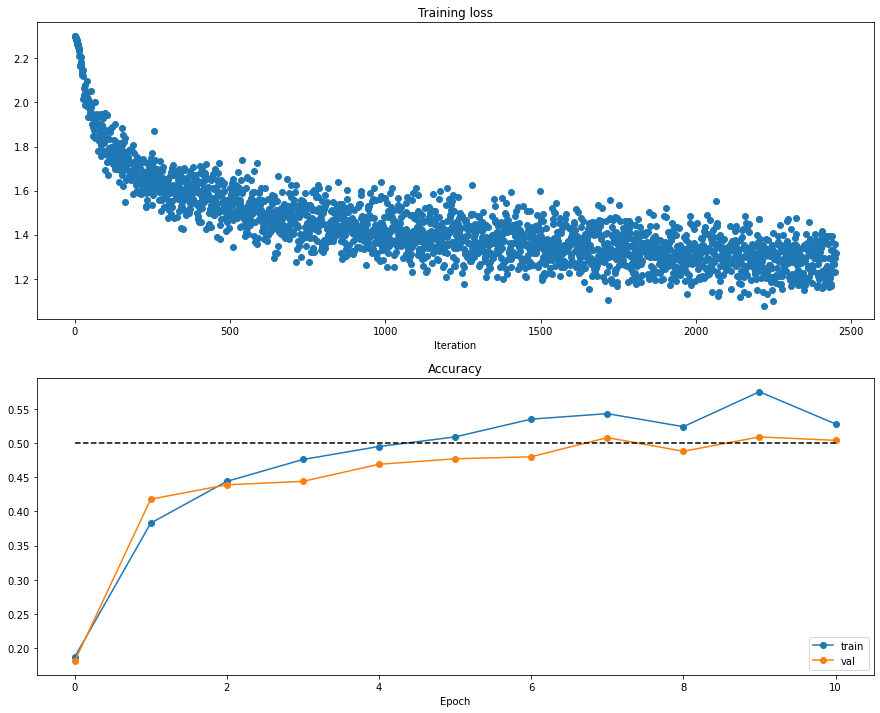

In [20]:
# Run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

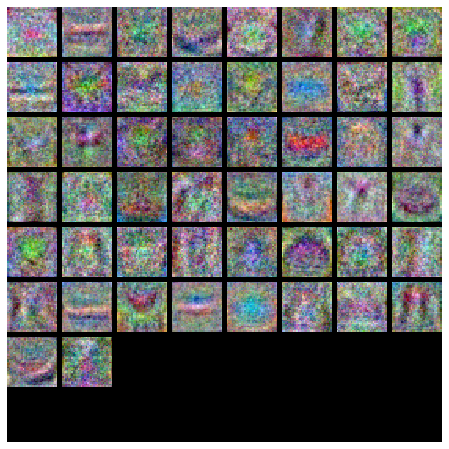

In [21]:
# Visualize the weights of the network

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(3, 32, 32, -1).transpose(3, 1, 2, 0)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(model)

## 12. Tune the hyperparameters

**What might be going wrong?**  
If the loss decreases only slowly and almost linearly, that often suggests the learning rate is too small.
If there is little or no gap between training and validation accuracy, that suggests the model may have too little capacity.

On the other hand, if the model becomes too large, then overfitting can become more severe, which would show up as a widening train/validation gap.

**Tuning practice.**  
A large part of neural-network work is developing intuition for hyperparameters. Here you should experiment with:
- hidden layer size,
- learning rate,
- number of epochs,
- regularization strength,
- and possibly learning-rate decay.

A reasonable target is **above 48% validation accuracy**. Reference implementations can exceed 52%, but the main goal here is to build practical intuition through experimentation.


In [22]:
best_model = None
best_val_acc = -1
best_stats = None

#################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_model.                                                          #
#################################################################################

hidden_sizes = [100, 200]
learning_rates = [1e-3, 3e-3]
regularization_strengths = [0.25, 0.5]

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regularization_strengths:

            model = TwoLayerNet(input_size, hs, num_classes, reg=reg)

            solver = Solver(
                model,
                data,
                update_rule='sgd',
                optim_config={'learning_rate': lr},
                lr_decay=0.95,
                num_epochs=10,
                batch_size=200,
                print_every=100,
                verbose=False
            )

            solver.train()

            val_acc = solver.best_val_acc
            train_acc = solver.train_acc_history[-1]

            print(
                f"hs={hs}, lr={lr}, reg={reg}, "
                f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
            )

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_stats = {
                    'hidden_size': hs,
                    'learning_rate': lr,
                    'reg': reg,
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                }

print("best_val_acc:", best_val_acc)
print("best_stats:", best_stats)

#################################################################################
#                              END OF YOUR CODE                                #
#################################################################################

hs=100, lr=0.001, reg=0.25, train_acc=0.5800, val_acc=0.5160
hs=100, lr=0.001, reg=0.5, train_acc=0.5620, val_acc=0.5160
hs=100, lr=0.003, reg=0.25, train_acc=0.5480, val_acc=0.4910
hs=100, lr=0.003, reg=0.5, train_acc=0.4560, val_acc=0.4960
hs=200, lr=0.001, reg=0.25, train_acc=0.6090, val_acc=0.5350
hs=200, lr=0.001, reg=0.5, train_acc=0.5990, val_acc=0.5350
hs=200, lr=0.003, reg=0.25, train_acc=0.5790, val_acc=0.5030
hs=200, lr=0.003, reg=0.5, train_acc=0.5340, val_acc=0.5130
best_val_acc: 0.535
best_stats: {'hidden_size': 200, 'learning_rate': 0.001, 'reg': 0.25, 'train_acc': 0.609, 'val_acc': 0.535}


## 13. Final evaluation

Run the best model on the validation and test sets.
A good two-layer network here should exceed roughly **48% validation accuracy**.


In [23]:
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())

Validation set accuracy:  0.535


In [24]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Test set accuracy:  0.535


In [26]:
# Save best model
best_model.save("best_two_layer_net.npy")

best_two_layer_net.npy saved.


### Discussion: how can we reduce a train-test gap?

After training a neural network, it is common to see training accuracy noticeably higher than test accuracy. That gap is a sign of **overfitting**.

**Question.** Which of the following can help reduce that gap?

1. Train on a larger dataset.  
2. Add more hidden units.  
3. Increase the regularization strength.  
4. None of the above.  

**Answer:** **1 and 3**

**Explanation.**

- **Train on a larger dataset:** yes. More data makes it harder for the model to memorize idiosyncrasies of the training set and usually improves generalization.
- **Add more hidden units:** usually no. This increases model capacity, which often makes overfitting worse rather than better.
- **Increase regularization strength:** yes. Stronger regularization discourages overly large or overly flexible weights and can reduce overfitting.
- **None of the above:** incorrect, since both **1** and **3** address the issue directly.
